# 03 — Embeddings y clustering de negociaciones — LockBit

Genera embeddings semánticos de los mensajes de negociación con `nomic-embed-text-v2-moe`,  
aplica UMAP + HDBSCAN para clustering y visualiza las tácticas de extorsión.

Con solo 4,423 mensajes (vs 195k en BlackBasta) se pueden embeber **todos**  
sin muestreo, y el heatmap operador×operador (35×35) sigue siendo legible.

Produce:
- `data/processed/chat_embeddings.npy`
- `data/processed/chats_with_embeddings.parquet`

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ollama
import umap
import hdbscan
from pathlib import Path
from tqdm.auto import tqdm

PROCESSED      = Path('../data/processed')
CHATS_CLASS    = PROCESSED / 'chats_classified.parquet'
USERS_IN       = PROCESSED / 'users.parquet'
EMBEDDINGS_NPY = PROCESSED / 'chat_embeddings.npy'
CHATS_OUT      = PROCESSED / 'chats_with_embeddings.parquet'

EMBED_MODEL = 'nomic-embed-text-v2-moe'
BATCH_SIZE  = 32

assert CHATS_CLASS.exists(), f'Falta {CHATS_CLASS} — ejecuta notebook 02'

classified = pd.read_parquet(CHATS_CLASS)
users      = pd.read_parquet(USERS_IN)

# Solo mensajes de texto con contenido
chats_emb = classified[classified.content.notna() & (classified.content.str.strip().str.len() > 3)].copy()

print(f'Mensajes a embeber: {len(chats_emb):,}')
print(f'Modelo de embeddings: {EMBED_MODEL}')
print('Setup OK')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mensajes a embeber: 3,977
Modelo de embeddings: nomic-embed-text-v2-moe
Setup OK


## 1. Generación de embeddings

Usa `ollama.embed()` — distinto de `ollama.chat()`.  
Devuelve `resp.embeddings`: lista de vectores de 768 dimensiones.

In [2]:
if EMBEDDINGS_NPY.exists():
    embeddings = np.load(EMBEDDINGS_NPY)
    print(f'Cargados desde caché: {embeddings.shape}')
else:
    texts = chats_emb['content'].tolist()
    all_vecs = []

    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Embeddings'):
        batch = [str(t)[:500] for t in texts[i:i+BATCH_SIZE]]
        resp = ollama.embed(model=EMBED_MODEL, input=batch)
        all_vecs.extend(resp.embeddings)

    embeddings = np.array(all_vecs, dtype=np.float32)
    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Embeddings calculados y guardados: {embeddings.shape}')

print(f'Dimensiones: {embeddings.shape[1]}D')

Embeddings: 100%|██████████████████████████████████████████████████████████████████████████| 125/125 [00:24<00:00,  5.15it/s]

Embeddings calculados y guardados: (3977, 768)
Dimensiones: 768D


## 2. Reducción dimensional con UMAP

In [3]:
print('Reduciendo a 2D con UMAP...')
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    n_components=2
)
coords_2d = reducer.fit_transform(embeddings)
print(f'UMAP completado: {coords_2d.shape}')

chats_emb = chats_emb.copy()
chats_emb['umap_x'] = coords_2d[:, 0]
chats_emb['umap_y'] = coords_2d[:, 1]

/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduciendo a 2D con UMAP...
UMAP completado: (3977, 2)


## 3. Clustering con HDBSCAN

In [4]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
clusters  = clusterer.fit_predict(coords_2d)

chats_emb['cluster'] = clusters
n_clusters = (np.unique(clusters) >= 0).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Ruido (cluster -1): {(clusters == -1).sum()} mensajes')
print()
print('Tamaño de clusters:')
for c in sorted(np.unique(clusters)):
    label = 'ruido' if c == -1 else f'cluster {c}'
    print(f'  {label}: {(clusters == c).sum()}')

Clusters encontrados: 57
Ruido (cluster -1): 895 mensajes

Tamaño de clusters:
  ruido: 895
  cluster 0: 217
  cluster 1: 40
  cluster 2: 26
  cluster 3: 22
  cluster 4: 44
  cluster 5: 60
  cluster 6: 23
  cluster 7: 90
  cluster 8: 20
  cluster 9: 53
  cluster 10: 36
  cluster 11: 68
  cluster 12: 42
  cluster 13: 20
  cluster 14: 27
  cluster 15: 87
  cluster 16: 48
  cluster 17: 24
  cluster 18: 39
  cluster 19: 27
  cluster 20: 24
  cluster 21: 25
  cluster 22: 72
  cluster 23: 53
  cluster 24: 37
  cluster 25: 24
  cluster 26: 116
  cluster 27: 31
  cluster 28: 77
  cluster 29: 57
  cluster 30: 22
  cluster 31: 60
  cluster 32: 34
  cluster 33: 87
  cluster 34: 228
  cluster 35: 67
  cluster 36: 54
  cluster 37: 39
  cluster 38: 52
  cluster 39: 83
  cluster 40: 96
  cluster 41: 21
  cluster 42: 28
  cluster 43: 38
  cluster 44: 54
  cluster 45: 25
  cluster 46: 122
  cluster 47: 51
  cluster 48: 26
  cluster 49: 26
  cluster 50: 36
  cluster 51: 22
  cluster 52: 41
  cluster 53:

## 4. Visualizaciones

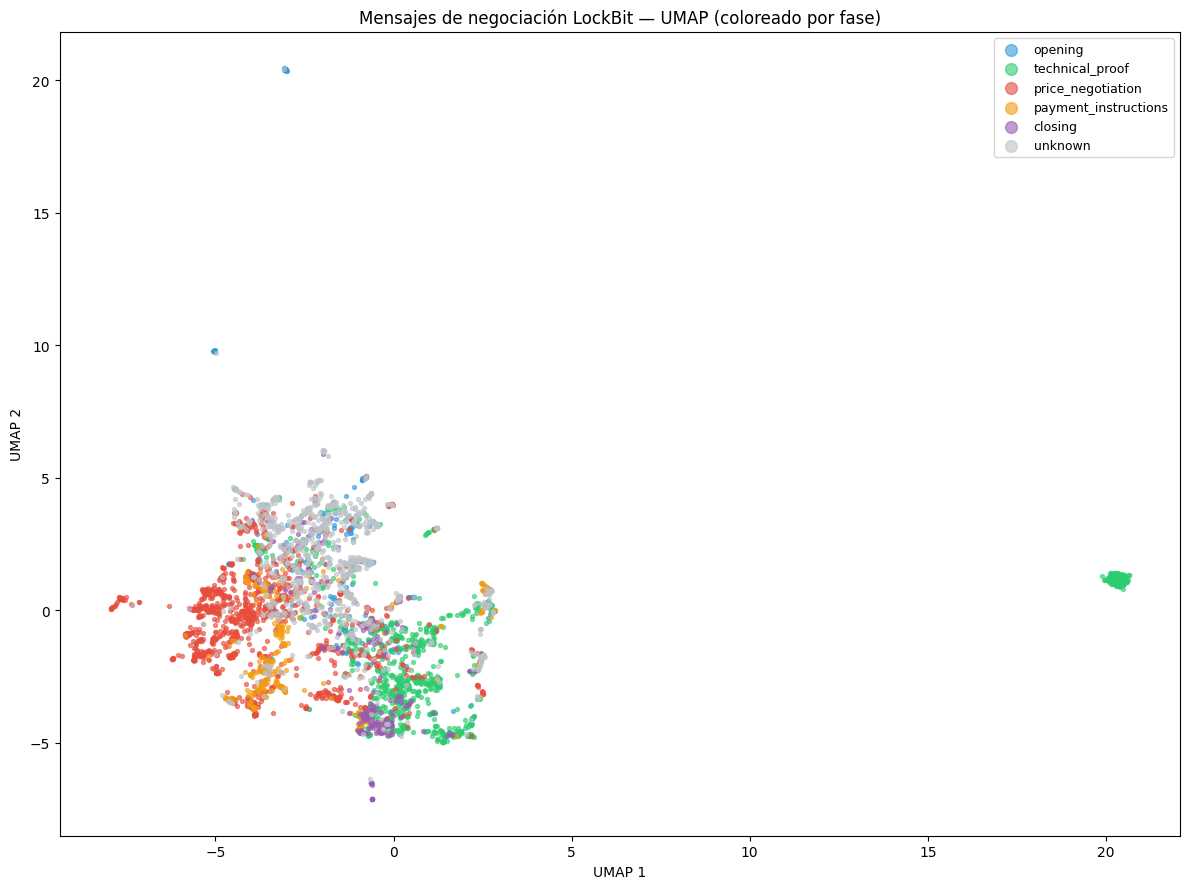

In [5]:
# Scatter coloreado por fase de negociación
phase_colors = {
    'opening': '#3498db',
    'technical_proof': '#2ecc71',
    'price_negotiation': '#e74c3c',
    'payment_instructions': '#f39c12',
    'closing': '#9b59b6',
    'unknown': '#bdc3c7'
}

fig, ax = plt.subplots(figsize=(12, 9))

for phase, color in phase_colors.items():
    mask = chats_emb['phase'] == phase
    if mask.sum() == 0:
        continue
    ax.scatter(
        chats_emb.loc[mask, 'umap_x'],
        chats_emb.loc[mask, 'umap_y'],
        c=color, s=8, alpha=0.6, label=phase, rasterized=True
    )

ax.set_title('Mensajes de negociación LockBit — UMAP (coloreado por fase)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

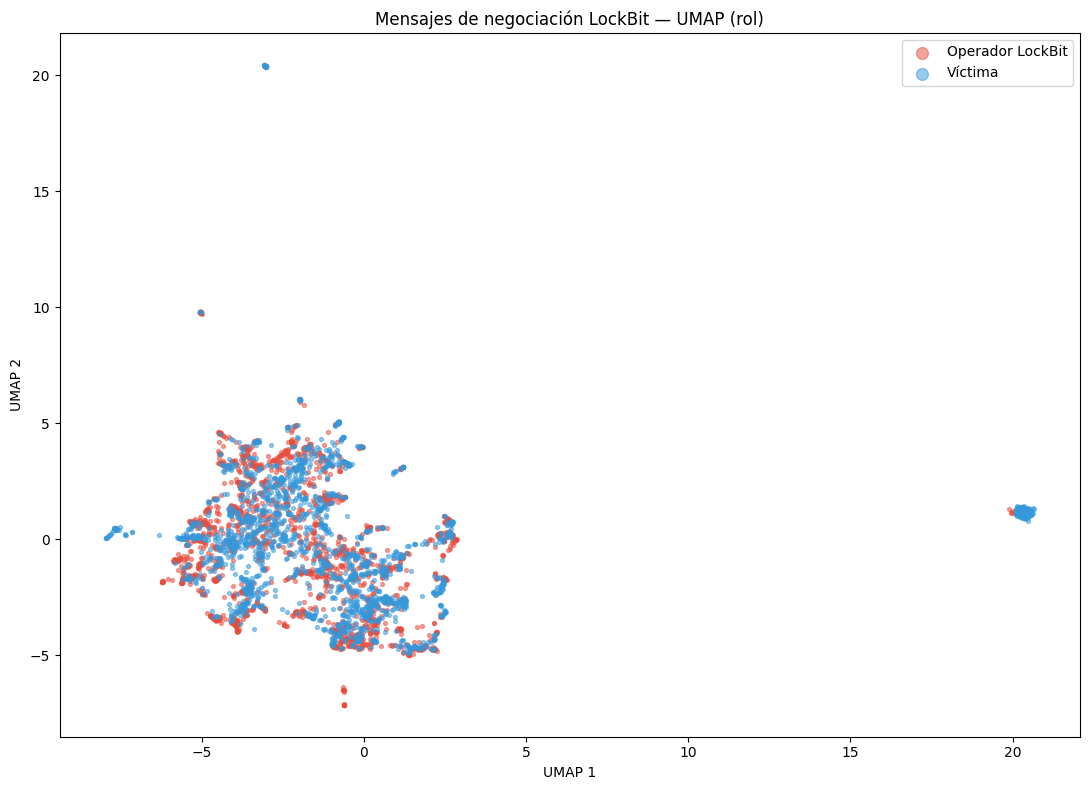

In [6]:
# Scatter coloreado por rol (operador vs víctima)
fig, ax = plt.subplots(figsize=(11, 8))

for flag, (label, color) in {1: ('Operador LockBit', '#e74c3c'), 0: ('Víctima', '#3498db')}.items():
    mask = chats_emb['flag'] == flag
    ax.scatter(
        chats_emb.loc[mask, 'umap_x'],
        chats_emb.loc[mask, 'umap_y'],
        c=color, s=8, alpha=0.5, label=label, rasterized=True
    )

ax.set_title('Mensajes de negociación LockBit — UMAP (rol)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 5. Similitud coseno entre operadores

Comparamos el estilo semántico de los operadores usando el centroide  
de sus embeddings. Con 35 operadores, la matriz es legible.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Solo mensajes enviados por operadores
op_msgs = chats_emb[chats_emb.flag == 1].copy()
op_msgs_idx = op_msgs.index.tolist()
chats_emb_list = chats_emb.index.tolist()

# Índices posicionales para acceder a embeddings
pos_map = {idx: i for i, idx in enumerate(chats_emb_list)}
op_msgs['emb_pos'] = op_msgs.index.map(pos_map)

# Calcular centroide por operador
op_centroids = {}
active_ops = op_msgs.groupby('advid').size()
active_ops = active_ops[active_ops >= 5].index.tolist()

for op_id in active_ops:
    positions = op_msgs[op_msgs.advid == op_id]['emb_pos'].tolist()
    vecs = embeddings[positions]
    centroid = vecs.mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    op_centroids[op_id] = centroid

print(f'Operadores con centroides: {len(op_centroids)}')

# Matriz de similitud
op_ids = list(op_centroids.keys())
centroid_matrix = np.array([op_centroids[oid] for oid in op_ids])
sim_matrix = cosine_similarity(centroid_matrix)

# Labels (usar login si disponible)
id_to_login = dict(zip(users.id, users.login))
labels = [id_to_login.get(oid, f'ID_{oid}') for oid in op_ids]

Operadores con centroides: 20


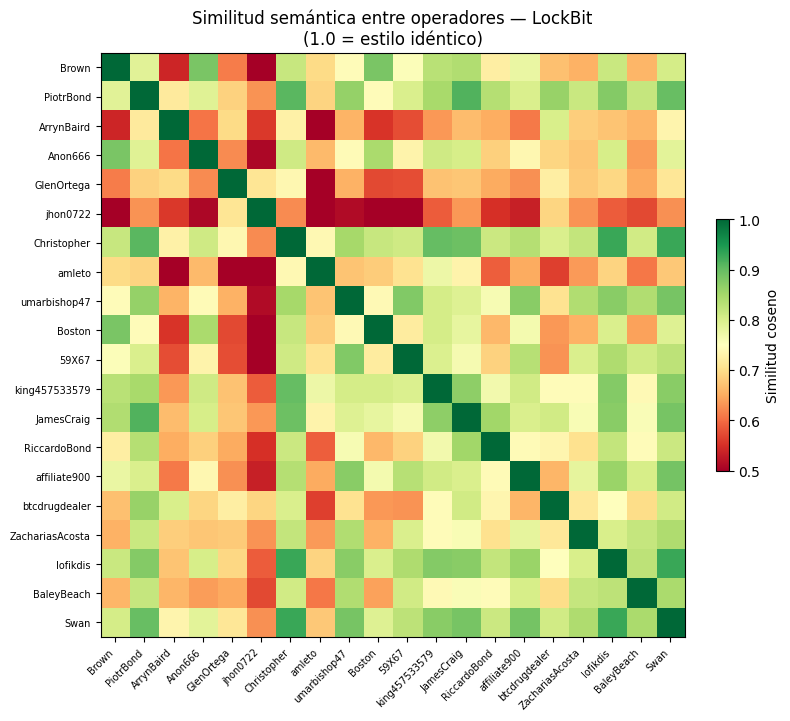

Top 5 pares de operadores con estilo más similar:
  Iofikdis             ↔ Swan                  sim=0.930
  Christopher          ↔ Swan                  sim=0.929
  Christopher          ↔ Iofikdis              sim=0.928
  PiotrBond            ↔ JamesCraig            sim=0.914
  PiotrBond            ↔ Christopher           sim=0.907


In [8]:
n = len(labels)
fig_size = max(8, n * 0.35)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02, label='Similitud coseno')
ax.set_title('Similitud semántica entre operadores — LockBit\n(1.0 = estilo idéntico)')
plt.tight_layout()
plt.show()

# Top pares más similares (excl. diagonal)
print('Top 5 pares de operadores con estilo más similar:')
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((sim_matrix[i,j], labels[i], labels[j]))
pairs.sort(reverse=True)
for sim, a, b in pairs[:5]:
    print(f'  {a:20s} ↔ {b:20s}  sim={sim:.3f}')

## 6. Guardar

In [9]:
# Guardar dataset con coordenadas UMAP y cluster
chats_emb.to_parquet(CHATS_OUT, index=False)

print(f'Embeddings      → {EMBEDDINGS_NPY}  ({embeddings.shape})')
print(f'Dataset enriquecido → {CHATS_OUT}')
print(f'\nResumen:')
print(f'  Mensajes embebidos : {len(chats_emb):,}')
print(f'  Clusters HDBSCAN   : {n_clusters}')
print(f'  Operadores analizados: {len(op_centroids)}')

Embeddings      → ../data/processed/chat_embeddings.npy  ((3977, 768))
Dataset enriquecido → ../data/processed/chats_with_embeddings.parquet

Resumen:
  Mensajes embebidos : 3,977
  Clusters HDBSCAN   : 57
  Operadores analizados: 20
